<a href="https://colab.research.google.com/github/PravallikaSomisetti/python/blob/main/zillionskills_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/student_performnance.csv.zip")  # Replace with your actual file path

# Show first few rows
print(df.head())

# Dataset info
print(df.info())


   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------              

In [2]:
# Check null values
print("\nMissing values:\n", df.isnull().sum())

# Optionally drop or fill missing values
df = df.dropna()  # OR use df.fillna(df.mean()) for numeric columns



Missing values:
 Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [3]:
# Summary statistics
print(df.describe())

# Check column names
print(df.columns)


       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        85.000000      8.000000   
max         9.000000        99.000000      9.000000   

       Sample Question Papers Practiced  Performance Index  
count                      10000.000000       10000.000000  
mean                           4.583300          55.224800  
std                            2.867348          19.212558  
min                            0.000000          10.000000  
25%                            2.000000          40.000000  
50%                            5.000000          55.000000  
75%                            7.000000          71.000000  
max             

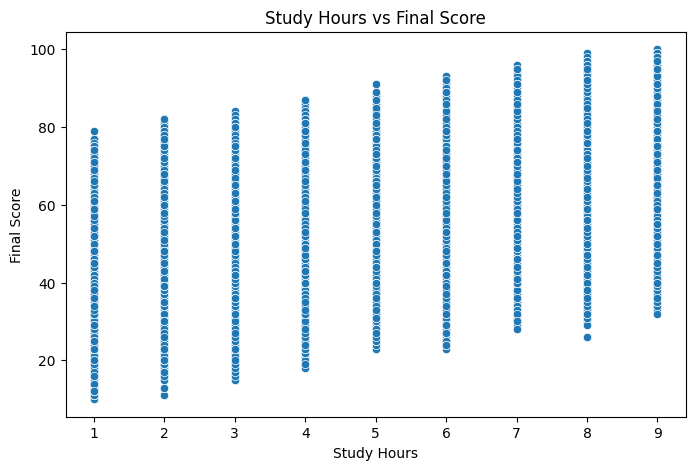

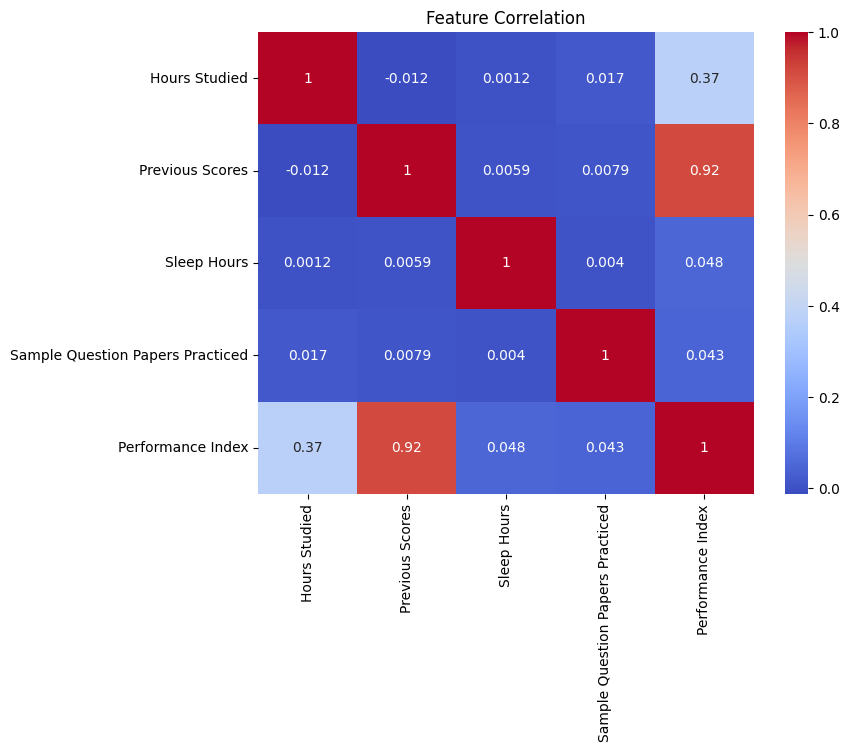

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: study hours vs final score
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Hours Studied", y="Performance Index")
plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

**Task 2**

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("/content/student_performnance.csv.zip")  # replace with your file name

# Check missing values
print("Missing values per column:\n", df.isnull().sum())

# Drop non-numeric columns that are not useful for analysis
df = df.drop(['id', 'first_name', 'last_name', 'email'], axis=1)

# Fill missing values (if any) for numeric columns only
df = df.fillna(df.mean(numeric_only=True))

Missing values per column:
 Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [11]:
scaler = MinMaxScaler()

# Selecting features to normalize
df[['Hours Studied', 'Previous Scores']] = scaler.fit_transform(df[['Hours Studied', 'Previous Scores']])

print(df.head())

   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0          0.750         1.000000                        Yes            9   
1          0.375         0.711864                         No            4   
2          0.875         0.186441                        Yes            7   
3          0.500         0.203390                        Yes            5   
4          0.750         0.593220                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


In [13]:
# Features & target
X = df[['Hours Studied', 'Previous Scores']]
y = df['Performance Index']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 8000
Testing samples: 2000


**Task 3**

   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  
Coefficients: [22.86523667 60.02492129]
Intercept: 13.8827565896813


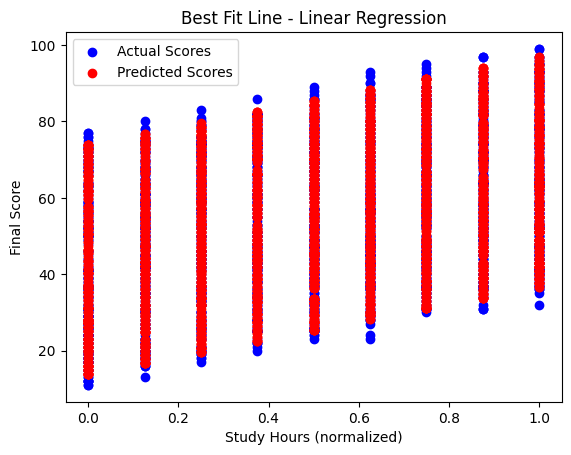

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------------
# 1. Load dataset
# ------------------------
df = pd.read_csv("/content/student_performnance.csv.zip")  # Replace with your dataset path

# Example columns: study_hours, past_scores, final_score
print(df.head())

# ------------------------
# 2. Handle missing values
# ------------------------
df = df.fillna(df.mean(numeric_only=True))

# ------------------------
# 3. Normalize numerical features
# ------------------------
scaler = MinMaxScaler()
df[['Hours Studied', 'Previous Scores']] = scaler.fit_transform(df[['Hours Studied', 'Previous Scores']])

# ------------------------
# 4. Split into train/test sets
# ------------------------
X = df[['Hours Studied', 'Previous Scores']]  # Features
y = df['Performance Index']                   # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------
# 5. Train Linear Regression model
# ------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# Get coefficients
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# ------------------------
# 6. Predict on test data
# ------------------------
y_pred = model.predict(X_test)

# ------------------------
# 7. Plot best-fit line (for single feature example)
# ------------------------
# If you want to visualize study_hours vs final_score only:
plt.scatter(X_test['Hours Studied'], y_test, color='blue', label='Actual Scores')
plt.scatter(X_test['Hours Studied'], y_pred, color='red', label='Predicted Scores')
plt.xlabel("Study Hours (normalized)")
plt.ylabel("Final Score")
plt.title("Best Fit Line - Linear Regression")
plt.legend()
plt.show()

**Task 4**

In [18]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd # Import pandas here

# ------------------------
# 1. Evaluate the model
# ------------------------
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# ------------------------
# 2. Predict final grades for new students
# ------------------------
# Example: new students with [study_hours, past_scores]
new_students = pd.DataFrame({
    'Hours Studied': [5, 8, 2],   # example values - Corrected column name
    'Previous Scores': [70, 85, 50] # example values - Corrected column name
})

# Normalize features using the same scaler from Task 3
new_students[['Hours Studied', 'Previous Scores']] = scaler.transform(new_students[['Hours Studied', 'Previous Scores']]) # Corrected column names

# Predict grades
predicted_grades = model.predict(new_students) # Corrected column names

# Show predictions
for i, grade in enumerate(predicted_grades):
    print(f"Student {i+1} - Predicted Final Grade: {grade:.2f}")

Mean Squared Error (MSE): 5.24
R² Score: 0.99
Student 1 - Predicted Final Grade: 55.84
Student 2 - Predicted Final Grade: 79.67
Student 3 - Predicted Final Grade: 26.91
